In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
epilepsy = pd.read_csv("Epilepsy_dataset.csv")

## 1) Quick EDA and variable pre-processing

In [6]:
print(epilepsy.shape)
print(epilepsy.head)

(4856, 30)
<bound method NDFrame.head of       Age  Gender  Weight  Height  Medication Status Alcohol or Drug Use  \
0      15    Male    48.3   168.2      On Medication                 Yes   
1       4  Female    56.0   174.5      On Medication                  No   
2      36  Female    44.8   156.2      On Medication                  No   
3      32  Female    70.4   180.4  Not on Medication                  No   
4      29    Male    54.5   161.7      On Medication                  No   
...   ...     ...     ...     ...                ...                 ...   
4851   76  Female    58.1   170.3      On Medication                  No   
4852   10    Male    80.6   172.9      On Medication                 Yes   
4853   67    Male    37.0   159.6      On Medication                  No   
4854   33    Male    54.7   156.5      On Medication                  No   
4855   49    Male    83.0   172.4  Not on Medication                  No   

     EEG Abnormality Detected MRI/CT Scan Resu

We have a total of 4856 samples, 29 predictors and 1 response.  

Given that a large majority of the predictors are categorical, we will need to perform one-hot encoding for categorical variables with multiple levels, and binary encoding for categorical variables with 2 levels. 

### Checking for NA values

In [8]:
# Check for NA values 
missing = epilepsy.isnull().sum().sum()
print(f"\nTotal missing values in dataset: {missing}")


Total missing values in dataset: 0


### Extracting the response y and looking at its unique values 

In [10]:
# Extract y 
y = epilepsy["Target/Epilepsy Type"]
x = epilepsy.drop(columns=["Target/Epilepsy Type"])
print(y.shape)
print(x.shape)

# Check the distribution of labels in the response variable 
print("\n")
print(y.value_counts())

# Change the response into a numeric categorical variable 
y = y.astype("category")
print("\n")
print(y.unique())

(4856,)
(4856, 29)


Target/Epilepsy Type
Generalized      2047
Focal            1413
Absence           616
Complicated       490
Normal            175
Not Confirmed     115
Name: count, dtype: int64


['Generalized', 'Focal', 'Absence', 'Complicated', 'Normal', 'Not Confirmed']
Categories (6, object): ['Absence', 'Complicated', 'Focal', 'Generalized', 'Normal', 'Not Confirmed']


### Visualizations of data 

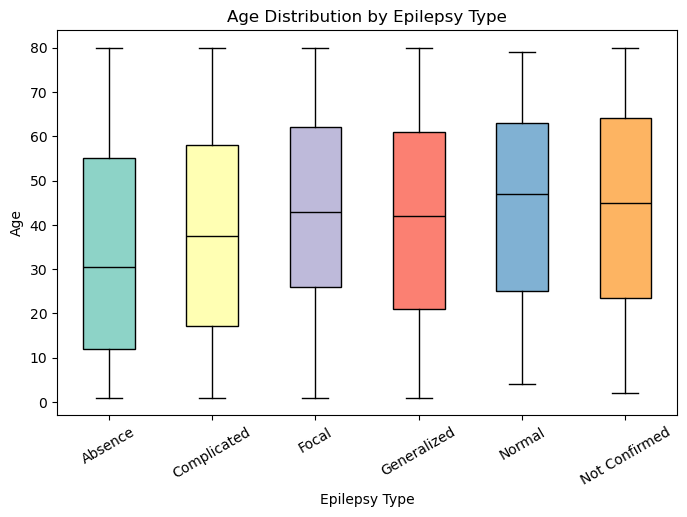

/var/folders/1t/w2vsmf1d19l3z_5kh93nc8m00000gn/T/ipykernel_42413/1294963501.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["epilepsy_type", "gender"])


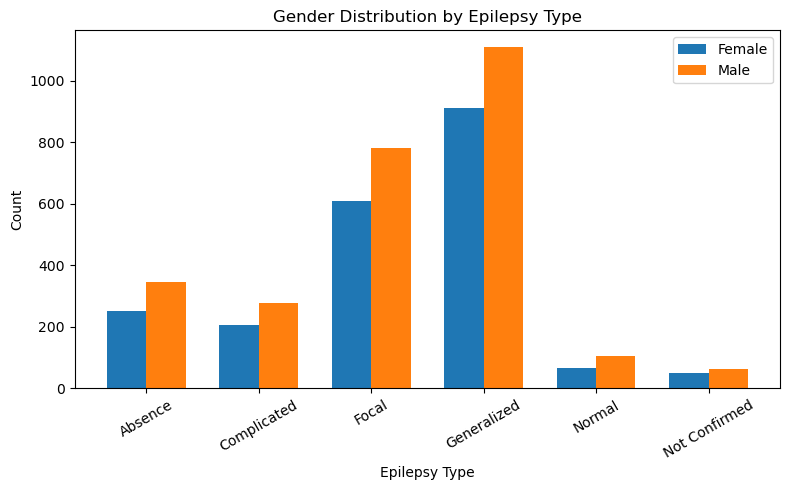

In [30]:
import matplotlib.pyplot as plt

# Distribution by age
data = [age[y == cat] for cat in y.cat.categories]
labels = y.cat.categories

colors = ["#8dd3c7", "#ffffb3", "#bebada", "#fb8072", "#80b1d3", "#fdb462"]

fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1)
)

for box, color in zip(bp["boxes"], colors):
    box.set_facecolor(color)

ax.set_xlabel("Epilepsy Type")
ax.set_ylabel("Age")
ax.set_title("Age Distribution by Epilepsy Type")
plt.xticks(rotation=30)
plt.show()


# Distribution by gender 
df = pd.DataFrame({"epilepsy_type": y, "gender": x["Gender"]})

counts = (df.groupby(["epilepsy_type", "gender"])
    .size()
    .unstack(fill_value=0))

labels = counts.index
female = counts["Female"]
male = counts["Male"]

x_pos = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x_pos - width/2, female, width, label="Female")
plt.bar(x_pos + width/2, male, width, label="Male")

plt.xticks(x_pos, labels, rotation=30)
plt.xlabel("Epilepsy Type")
plt.ylabel("Count")
plt.title("Gender Distribution by Epilepsy Type")
plt.legend()

plt.tight_layout()
plt.show()

### Splitting the columns into numeric and categorical data for easier pre-processing

In [13]:
numeric_cols = x.select_dtypes(include=['int64','float64']).columns
categorical_cols = x.select_dtypes(include=['object', 'category']).columns
print(numeric_cols)
print(categorical_cols)

# Program took seizure frequency and duration to be numeric - however, on closer inspection they seem to be categorical numeric values. 
# We will include them in the categorical variables 
x['Seizure Frequency'] = x['Seizure Frequency'].astype('category')
x['Seizure Duration'] = x['Seizure Duration'].astype('category')

numeric_cols = x.select_dtypes(include=['int64','float64']).columns
categorical_cols = x.select_dtypes(include=['object', 'category']).columns
print(f"\nFinal numeric cols:", numeric_cols)
print(f"Final categorical cols:", categorical_cols)

# further extracting binary categorical columns from categorical_cols
binary_cols = [col for col in categorical_cols if x[col].nunique() == 2]
multi_cat_cols = [col for col in categorical_cols if x[col].nunique() > 2]

binary_df = x[binary_cols].copy()
multi_cat_df = x[multi_cat_cols].copy()
numeric_df = x[numeric_cols].copy()

print(f"\nShape of binary_df:", binary_df.shape)
print(f"Shape of multi_cat_df:", multi_cat_df.shape)
print(f"Shape of numeric_df:", numeric_df.shape)

Index(['Age', 'Weight', 'Height', 'Seizure Frequency', 'Seizure Duration'], dtype='object')
Index(['Gender', 'Medication Status', 'Alcohol or Drug Use',
       'EEG Abnormality Detected', 'MRI/CT Scan Result', 'Seizure Type',
       'Aura Before Seizure', 'Loss of Consciousness', 'Muscle Stiffness',
       'Jerky Movements', 'Postictal Confusion', 'Blank Stare Episodes',
       'Eye Rolling', 'Stress or Anxiety Before Episode',
       'Lack of Sleep Before Episode', 'Flashing Lights Sensitivity',
       'Loud Sound Sensitivity', 'Missed Medication',
       'Family History of Epilepsy', 'Head Injury History', 'Brain Tumor',
       'History of Stroke', 'Genetic Disorder',
       'Developmental Delay (in Children)'],
      dtype='object')

Final numeric cols: Index(['Age', 'Weight', 'Height'], dtype='object')
Final categorical cols: Index(['Gender', 'Medication Status', 'Alcohol or Drug Use',
       'EEG Abnormality Detected', 'MRI/CT Scan Result', 'Seizure Frequency',
       'Seizure Dur

In [15]:
# Binary encoding for binary categorical columns 
for col in binary_cols:
    binary_df[col], _ = pd.factorize(binary_df[col])

binary_df.head

<bound method NDFrame.head of       Medication Status  Alcohol or Drug Use  EEG Abnormality Detected  \
0                     0                    0                         0   
1                     0                    1                         0   
2                     0                    1                         0   
3                     1                    1                         0   
4                     0                    1                         0   
...                 ...                  ...                       ...   
4851                  0                    1                         0   
4852                  0                    0                         0   
4853                  0                    1                         0   
4854                  0                    1                         1   
4855                  1                    1                         1   

      Aura Before Seizure  Loss of Consciousness  Muscle Stiffness  \
0          

In [17]:
# One-hot encoding for multi-level categorical predictors

multi_cat_encoded = pd.get_dummies(multi_cat_df, drop_first=False,dtype=int)

count = 0
for col in multi_cat_cols:
    print("Unique values in", col, ":", multi_cat_df[col].unique())
    count += multi_cat_df[col].nunique()

print("\nTotal number of expected columns in multi_cat_encoded:", count)
print("\nActual shape of multi_cat_encoded:", multi_cat_encoded.shape)
print("\n")
print(multi_cat_encoded.head())

Unique values in Gender : ['Male' 'Female' 'Other']
Unique values in MRI/CT Scan Result : ['Normal' 'Abnormal' 'Not Done']
Unique values in Seizure Frequency : [1, 3, 0, 2, 5, 10]
Categories (6, int64): [0, 1, 2, 3, 5, 10]
Unique values in Seizure Duration : [60, 30, 90, 120]
Categories (4, int64): [30, 60, 90, 120]
Unique values in Seizure Type : ['Tonic-Clonic' 'Generalized' 'Focal' 'Absence']

Total number of expected columns in multi_cat_encoded: 20

Actual shape of multi_cat_encoded: (4856, 20)


   Gender_Female  Gender_Male  Gender_Other  MRI/CT Scan Result_Abnormal  \
0              0            1             0                            0   
1              1            0             0                            1   
2              1            0             0                            1   
3              1            0             0                            0   
4              0            1             0                            0   

   MRI/CT Scan Result_Normal  MRI/CT

In [19]:
# View numeric predictors

numeric_df.head

<bound method NDFrame.head of       Age  Weight  Height
0      15    48.3   168.2
1       4    56.0   174.5
2      36    44.8   156.2
3      32    70.4   180.4
4      29    54.5   161.7
...   ...     ...     ...
4851   76    58.1   170.3
4852   10    80.6   172.9
4853   67    37.0   159.6
4854   33    54.7   156.5
4855   49    83.0   172.4

[4856 rows x 3 columns]>

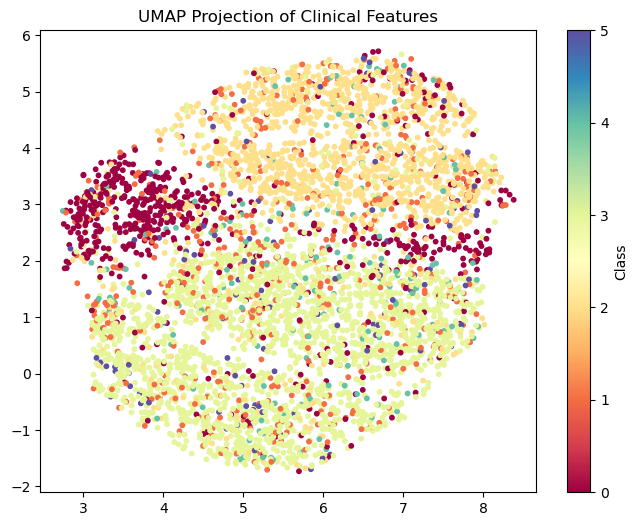

In [42]:
# UMAP

import umap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean"
)

numeric_scaled = pd.DataFrame(StandardScaler().fit_transform(numeric_df))
x_umap = pd.concat([numeric_scaled, binary_df, multi_cat_encoded], axis=1)
y_umap = y.astype("category").cat.codes

embedding = reducer.fit_transform(x_umap) 

plt.figure(figsize=(8,6))
plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y_umap, cmap='Spectral', s=10
)
plt.colorbar(label='Class')
plt.title("UMAP Projection of Clinical Features")
plt.savefig("UMAP.png")

In [40]:
y_cat = y.astype("category")
code_to_class = dict(enumerate(y_cat.cat.categories))
code_to_class

{0: 'Absence',
 1: 'Complicated',
 2: 'Focal',
 3: 'Generalized',
 4: 'Normal',
 5: 'Not Confirmed'}

### Other EDA visuals

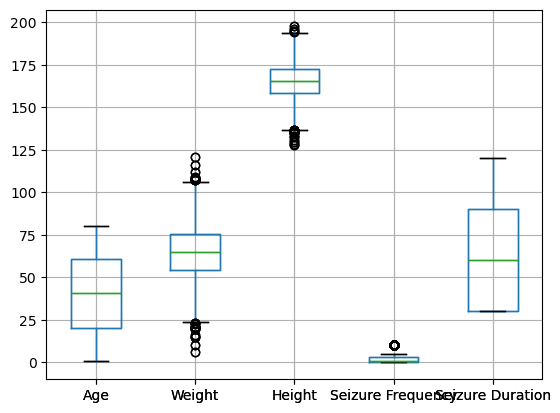

In [64]:
df_t = pd.read_csv("Epilepsy_dataset.csv")
df_t.boxplot()
plt.show()

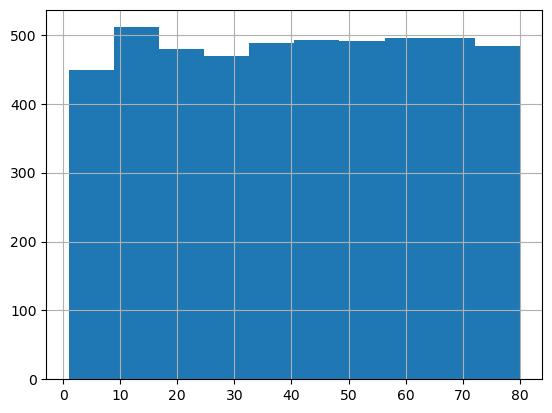

In [66]:
df_t["Age"].hist()
plt.show()

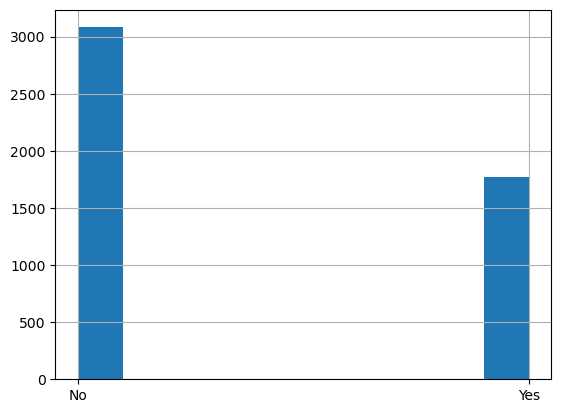

In [68]:
df_t["Family History of Epilepsy"].hist()
plt.show()

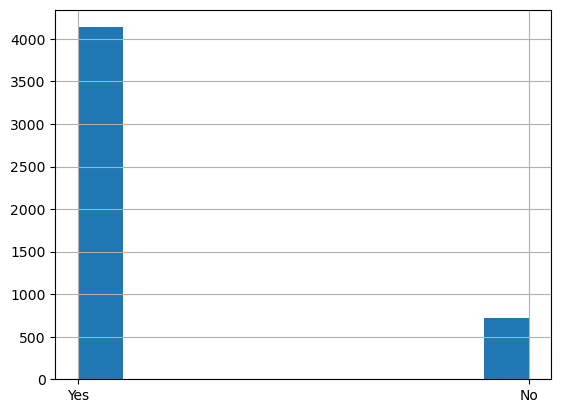

In [70]:
df_t["EEG Abnormality Detected"].hist()
plt.show()

C:\Users\Trish\AppData\Local\Temp\ipykernel_21272\4015955041.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_t[yes_no_cols] = df_t[yes_no_cols].replace({'Yes': True, 'No': False})
C:\Users\Trish\AppData\Local\Temp\ipykernel_21272\4015955041.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_t["Medication Status"] = df_t["Medication Status"].replace({'On Medication': True, 'Not on Medication': False})


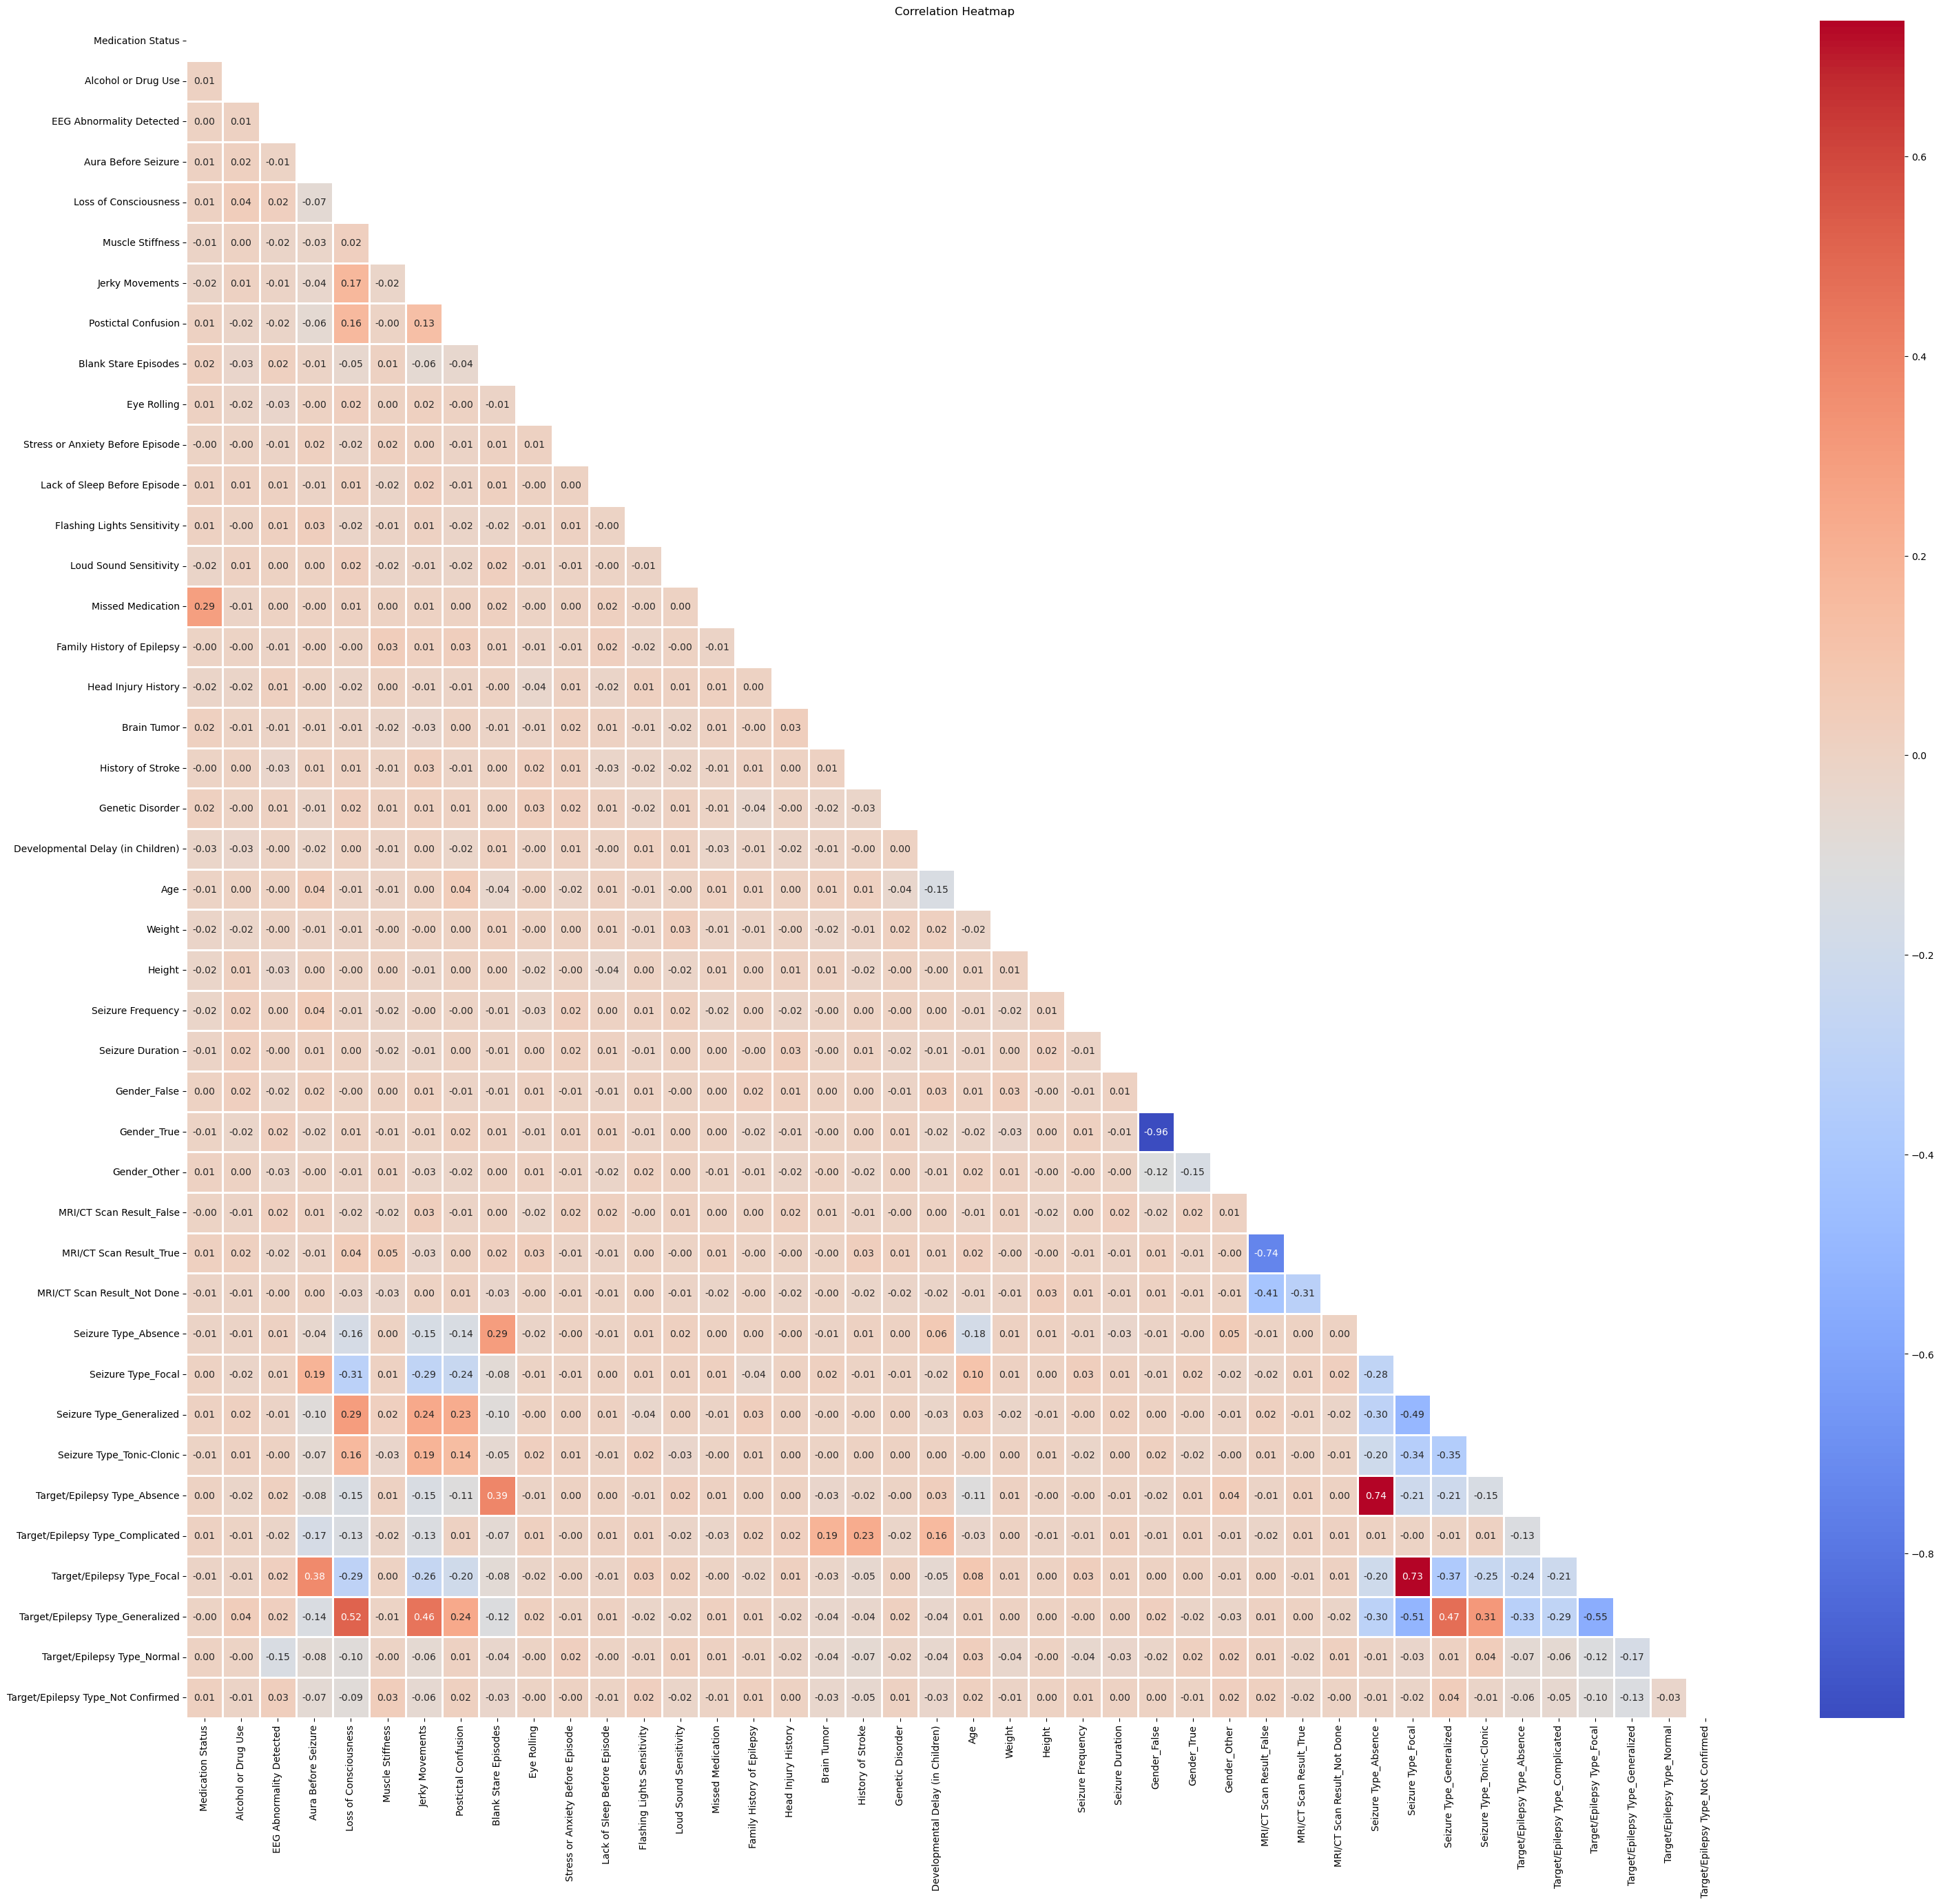

In [72]:
yes_no_cols = ['EEG Abnormality Detected', 'Alcohol or Drug Use','Aura Before Seizure', 'Loss of Consciousness', 'Muscle Stiffness',
       'Jerky Movements', 'Postictal Confusion', 'Blank Stare Episodes',
       'Eye Rolling', 'Stress or Anxiety Before Episode',
       'Lack of Sleep Before Episode', 'Flashing Lights Sensitivity',
       'Loud Sound Sensitivity', 'Missed Medication',
       'Family History of Epilepsy', 'Head Injury History', 'Brain Tumor',
       'History of Stroke', 'Genetic Disorder',
       'Developmental Delay (in Children)',]

# Convert certain columns to bools for correlation matrix
df_t[yes_no_cols] = df_t[yes_no_cols].replace({'Yes': True, 'No': False})
df_t["Gender"] = df_t["Gender"].replace({'Male': True, 'Female': False})
df_t["Medication Status"] = df_t["Medication Status"].replace({'On Medication': True, 'Not on Medication': False})
df_t["MRI/CT Scan Result"] = df_t["MRI/CT Scan Result"].replace({'Abnormal': True, 'Normal': False})
df_t

select_cols_t = df_t.select_dtypes(include=['object','int64', 'float64']).columns
boolean_df_t = df_t.select_dtypes(include=['bool'])
model_df_t = df_t
dummy_df_t = pd.get_dummies(df_t[select_cols_t], dtype=int)
final_df_t = pd.concat([boolean_df_t, dummy_df_t], axis=1)
final_df_t.to_csv('output.csv', index=False) 
final_df_t

m_t = final_df_t.corr()

mask = np.triu(np.ones_like(m_t, dtype=bool))
plt.figure(figsize=(36,32))
sns.heatmap(m,mask = mask, annot=True, cmap="coolwarm", fmt=".2f", linewidths=1)
plt.title("Correlation Heatmap")
#plt.savefig("heatmap.jpg")
plt.show()

In [40]:
df_t = pd.read_csv("Epilepsy_dataset.csv")
yes_no_cols = ['EEG Abnormality Detected', 'Alcohol or Drug Use','Aura Before Seizure', 'Loss of Consciousness', 'Muscle Stiffness',
       'Jerky Movements', 'Postictal Confusion', 'Blank Stare Episodes',
       'Eye Rolling', 'Stress or Anxiety Before Episode',
       'Lack of Sleep Before Episode', 'Flashing Lights Sensitivity',
       'Loud Sound Sensitivity', 'Missed Medication',
       'Family History of Epilepsy', 'Head Injury History', 'Brain Tumor',
       'History of Stroke', 'Genetic Disorder',
       'Developmental Delay (in Children)',]

# Convert inherent bools to bools
df_t[yes_no_cols] = df_t[yes_no_cols].replace({'Yes': 1, 'No': 0})
p = df_t.pivot_table(values =['Eye Rolling', 'Loud Sound Sensitivity', 'Aura Before Seizure', 'Blank Stare Episodes'], columns = 'Target/Epilepsy Type', index = None, aggfunc = 'sum')
p

C:\Users\Trish\AppData\Local\Temp\ipykernel_21272\1496402767.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_t[yes_no_cols] = df_t[yes_no_cols].replace({'Yes': 1, 'No': 0})


Target/Epilepsy Type,Absence,Complicated,Focal,Generalized,Normal,Not Confirmed
Aura Before Seizure,289,162,1223,1010,65,41
Blank Stare Episodes,519,123,423,588,46,29
Eye Rolling,366,306,839,1261,105,68
Loud Sound Sensitivity,265,183,588,807,76,38


In [42]:
colors = ['red', 'green', 'blue', 'purple', 'pink', 'maroon']

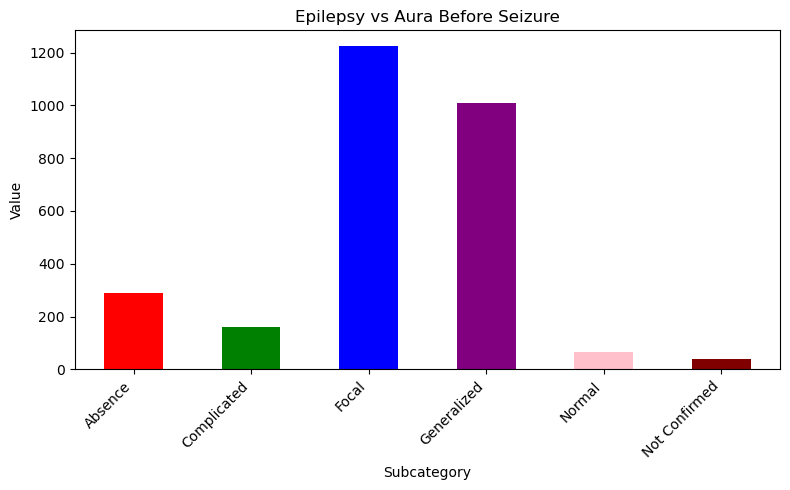

In [44]:
selected_row = p.loc['Aura Before Seizure']
plt.figure(figsize=(8, 5))
selected_row.plot.bar(color = colors)
plt.title(f'Epilepsy vs Aura Before Seizure')
plt.xlabel('Subcategory')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

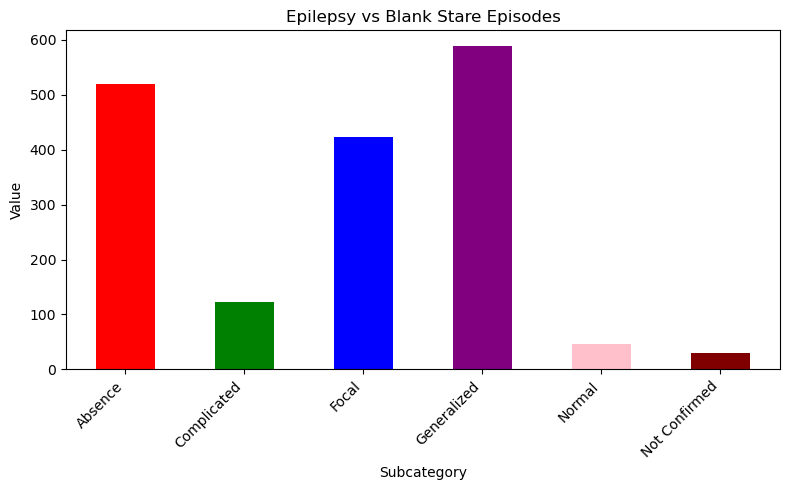

In [46]:
selected_row = p.loc['Blank Stare Episodes']
plt.figure(figsize=(8, 5))
selected_row.plot.bar(color = colors)
plt.title(f'Epilepsy vs Blank Stare Episodes')
plt.xlabel('Subcategory')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

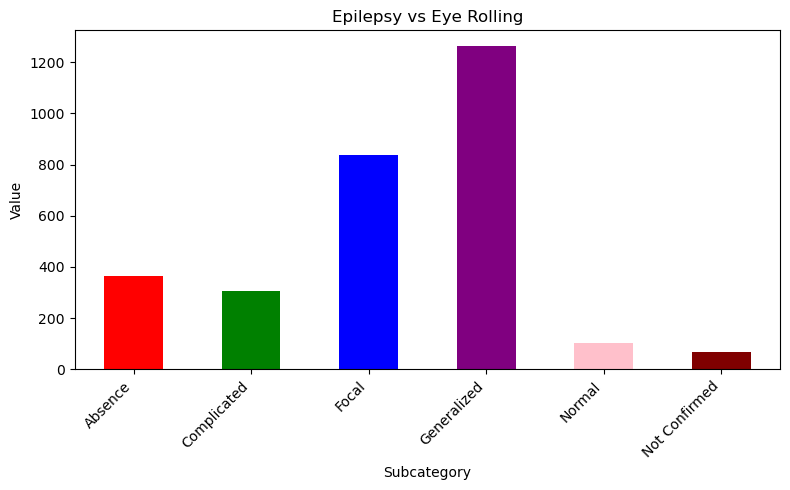

In [48]:
selected_row = p.loc['Eye Rolling']
plt.figure(figsize=(8, 5))
selected_row.plot.bar(color = colors)
plt.title(f'Epilepsy vs Eye Rolling')
plt.xlabel('Subcategory')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout() 
plt.show()

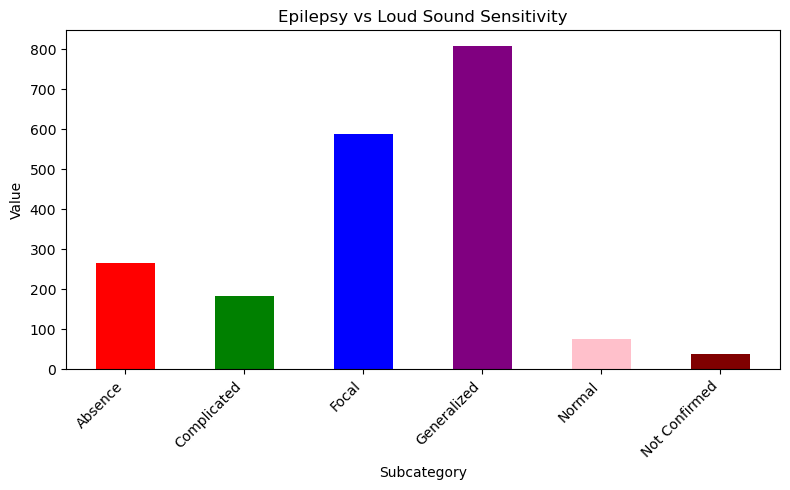

In [50]:
selected_row = p.loc['Loud Sound Sensitivity']
plt.figure(figsize=(8, 5))
selected_row.plot.bar(color = colors)
plt.title(f'Epilepsy vs Loud Sound Sensitivity')
plt.xlabel('Subcategory')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

EPILEPSY DATASET - COMPREHENSIVE EDA

1. DATASET OVERVIEW

Dataset Shape: 4856 rows × 30 columns
Memory Usage: 7.21 MB

--- Column Data Types ---
object     25
int64       3
float64     2
Name: count, dtype: int64

--- First 5 Rows ---
   Age  Gender  Weight  Height  Medication Status Alcohol or Drug Use  \
0   15    Male    48.3   168.2      On Medication                 Yes   
1    4  Female    56.0   174.5      On Medication                  No   
2   36  Female    44.8   156.2      On Medication                  No   
3   32  Female    70.4   180.4  Not on Medication                  No   
4   29    Male    54.5   161.7      On Medication                  No   

  EEG Abnormality Detected MRI/CT Scan Result  Seizure Frequency  \
0                      Yes             Normal                  1   
1                      Yes           Abnormal                  1   
2                      Yes           Abnormal                  3   
3                      Yes           Not Done        

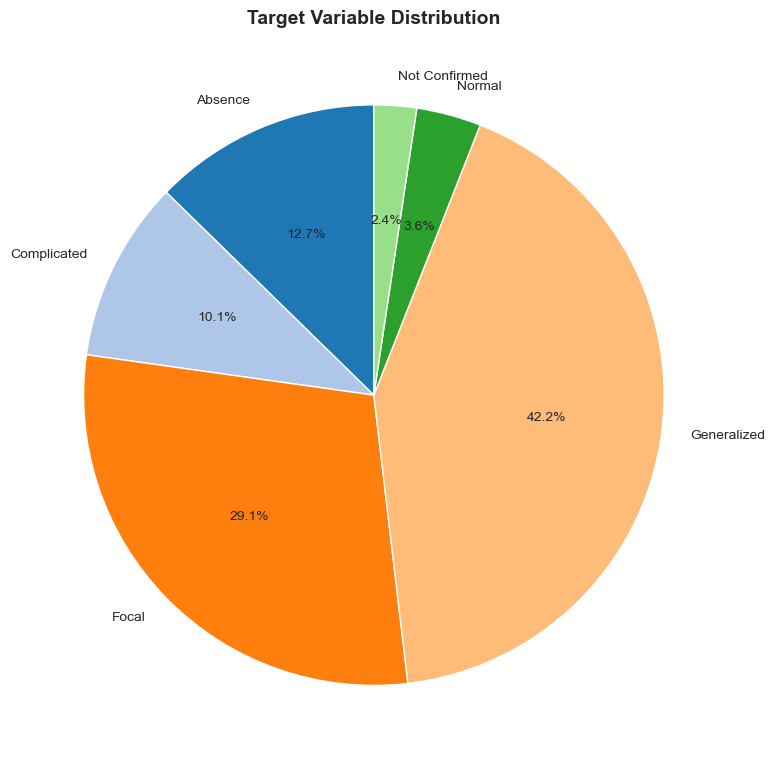

In [5]:
# Configure plotting aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


# Load Data

ep = pd.read_csv("Epilepsy_dataset.csv")

print("EPILEPSY DATASET - COMPREHENSIVE EDA")



# DATASET OVERVIEW
print("\n" + "="*80)
print("1. DATASET OVERVIEW")
print(f"\nDataset Shape: {ep.shape[0]} rows × {ep.shape[1]} columns")
print(f"Memory Usage: {ep.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n--- Column Data Types ---")
print(ep.dtypes.value_counts())

print("\n--- First 5 Rows ---")
print(ep.head())


# DATA QUALITY ASSESSMENT

print("\n" + "="*80)
print("DATA QUALITY ASSESSMENT")


# Missing values
missing_data = pd.DataFrame({
    'Column': ep.columns,
    'Missing_Count': ep.isnull().sum(),
    'Missing_Percentage': (ep.isnull().sum() / len(ep) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    print("\n--- Missing Values ---")
    print(missing_data.to_string(index=False))
else:
    print("\n No missing values detected")

# Duplicate rows
duplicates = ep.duplicated().sum()
print(f"\n--- Duplicate Rows ---")
print(f"Total duplicates: {duplicates} ({duplicates/len(ep)*100:.2f}%)")


# TARGET VARIABLE ANALYSIS

print("\n" + "="*80)
print("TARGET VARIABLE ANALYSIS")


target_col = "Target/Epilepsy Type"
y = ep[target_col]

print("\n--- Target Distribution ---")
target_counts = y.value_counts().sort_index()
target_pcts = y.value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'Class': target_counts.index,
    'Count': target_counts.values,
    'Percentage': target_pcts.values.round(2)
})
print(target_summary.to_string(index=False))

# Class imbalance ratio
max_class = target_counts.max()
min_class = target_counts.min()
imbalance_ratio = max_class / min_class
print(f"\n--- Class Imbalance Analysis ---")
print(f"Imbalance Ratio (max/min): {imbalance_ratio:.2f}")
if imbalance_ratio > 3:
    print(" Dataset has severe class imbalance. Could potentially use SMOTE, class weights, and/or stratified sampling")
elif imbalance_ratio > 1.5:
    print("Dataset has moderate class imbalance. Could potentially use class weights")
else:
    print(" Dataset has Balanced classes")

# Visualize target distribution with a single pie chart
plt.figure(figsize=(8, 8))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
        startangle=90, colors=plt.cm.tab20.colors)
plt.title('Target Variable Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
#plt.savefig('target_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

## 2) Putting the data together and splitting into train/test sets

In [20]:
# Putting all predictors back together 
x_processed = pd.concat([numeric_df, binary_df, multi_cat_encoded], axis=1)
print(x_processed.head())

# Split into training and test sets 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_processed, y, test_size=0.2, stratify=y, random_state=42)
print("\n")
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

# Changing the categories into numeric codes for modelling
y_train = y_train.astype("category").cat.codes
y_test  = y_test.astype("category").cat.codes

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

   Age  Weight  Height  Medication Status  Alcohol or Drug Use  \
0   15    48.3   168.2                  0                    0   
1    4    56.0   174.5                  0                    1   
2   36    44.8   156.2                  0                    1   
3   32    70.4   180.4                  1                    1   
4   29    54.5   161.7                  0                    1   

   EEG Abnormality Detected  Aura Before Seizure  Loss of Consciousness  \
0                         0                    0                      0   
1                         0                    1                      0   
2                         0                    1                      1   
3                         0                    1                      0   
4                         0                    0                      0   

   Muscle Stiffness  Jerky Movements  ...  Seizure Frequency_5  \
0                 0                0  ...                    0   
1                 1 

## 3) Training the data using various models

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# This creates a StandardScaler() for techniques like logistic regression that requires scaled data 
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', 'passthrough', [col for col in X_train.columns if col not in numeric_cols])
    ]
)

# Building pipelines for each model 
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

n_classes = len(np.unique(y_train))

models = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocess),
        ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=2000))
    ]),

    "SVM (RBF)": Pipeline([
        ("preprocess", preprocess),
        ("clf", SVC(
            kernel='rbf',
            probability=True))
    ]),

    "KNN": Pipeline([
        ("preprocess", preprocess),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),

    # Tree-based models (no scaling)
    "Random Forest": RandomForestClassifier(
        max_features="sqrt",
        n_estimators=300,
        random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(),

    "Cat Boost": CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function='MultiClass',
    verbose=False,
    random_seed=42),

    "XGBoost": XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',  # multi-class probabilities
    num_class=n_classes,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42)
}

# Model evaluation pipeline
from sklearn.metrics import accuracy_score, f1_score

def evaluate_models(models, X_train, y_train, X_test, y_test):
    results = []

    for name, model in models.items():
        print(f"\n===== Training {name} =====")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, average='weighted')

        results.append((name, acc, f1))

        print(f"Accuracy: {acc:.4f}")
        print(f"F1-score (weighted): {f1:.4f}")

    return results

In [40]:
evaluate_models(models, X_train, y_train, X_test, y_test)


===== Training Logistic Regression =====
Accuracy: 0.7984
F1-score (weighted): 0.7751

===== Training SVM (RBF) =====
Accuracy: 0.7860
F1-score (weighted): 0.7534

===== Training KNN =====
Accuracy: 0.7233
F1-score (weighted): 0.6810

===== Training Random Forest =====
Accuracy: 0.7953
F1-score (weighted): 0.7689

===== Training Gradient Boosting =====
Accuracy: 0.8230
F1-score (weighted): 0.8143

===== Training Cat Boost =====
Accuracy: 0.8117
F1-score (weighted): 0.8020

===== Training XGBoost =====
Accuracy: 0.8128
F1-score (weighted): 0.8017


[('Logistic Regression', 0.7983539094650206, 0.775099646878556),
 ('SVM (RBF)', 0.7860082304526749, 0.7533553693223763),
 ('KNN', 0.7232510288065843, 0.6809804975639471),
 ('Random Forest', 0.7952674897119342, 0.7688581838294337),
 ('Gradient Boosting', 0.823045267489712, 0.8143037770241095),
 ('Cat Boost', 0.8117283950617284, 0.8020093851820803),
 ('XGBoost', 0.8127572016460906, 0.8017001183838762)]

Based on the above results, tree-based models seem to perform the best amongst all classification models, with gradient boosting having both the highest accuracy and F1 score. 

We will tune the hyperparameters for both gradient boosting and XGBoost, since XGBoost has more robust regularization and may outperform gradient boosting after tuning. 

In [53]:
## Tuning the parameters of the gradient boosting model

n_list = [50, 100, 150, 200, 300]
lr_list = [0.05, 0.1, 0.2, 0.3, 0.5]
depth_list = [2, 3, 4, 5]

results = []

for n in n_list:
    for r in lr_list:
        for d in depth_list:
            gb = GradientBoostingClassifier(
                n_estimators=n,
                learning_rate=r,
                max_depth=d,
                random_state=42
            )

            gb.fit(X_train, y_train)
            y_pred = gb.predict(X_test)

            f1 = f1_score(y_test, y_pred, average="weighted")
            acc = accuracy_score(y_test, y_pred)

            results.append((n, r, d, f1, acc))
            print(f"n={n:<4} | lr={r:<4} | depth={d} | "
                  f"F1={f1:.4f} | Acc={acc:.4f}")

n=50   | lr=0.05 | depth=2 | F1=0.7920 | Acc=0.8117
n=50   | lr=0.05 | depth=3 | F1=0.8017 | Acc=0.8179
n=50   | lr=0.05 | depth=4 | F1=0.7957 | Acc=0.8117
n=50   | lr=0.05 | depth=5 | F1=0.7910 | Acc=0.8086
n=50   | lr=0.1  | depth=2 | F1=0.7992 | Acc=0.8179
n=50   | lr=0.1  | depth=3 | F1=0.8015 | Acc=0.8148
n=50   | lr=0.1  | depth=4 | F1=0.7898 | Acc=0.8014
n=50   | lr=0.1  | depth=5 | F1=0.7967 | Acc=0.8076
n=50   | lr=0.2  | depth=2 | F1=0.8004 | Acc=0.8138
n=50   | lr=0.2  | depth=3 | F1=0.8086 | Acc=0.8169
n=50   | lr=0.2  | depth=4 | F1=0.8081 | Acc=0.8158
n=50   | lr=0.2  | depth=5 | F1=0.7953 | Acc=0.8076
n=50   | lr=0.3  | depth=2 | F1=0.8085 | Acc=0.8189
n=50   | lr=0.3  | depth=3 | F1=0.8071 | Acc=0.8158
n=50   | lr=0.3  | depth=4 | F1=0.7953 | Acc=0.8035
n=50   | lr=0.3  | depth=5 | F1=0.8001 | Acc=0.8117
n=50   | lr=0.5  | depth=2 | F1=0.7979 | Acc=0.8076
n=50   | lr=0.5  | depth=3 | F1=0.8062 | Acc=0.8128
n=50   | lr=0.5  | depth=4 | F1=0.7959 | Acc=0.8014
n=50   | lr=

In [64]:
df_results = pd.DataFrame(
    results,
    columns=["n", "lr", "depth", "f1", "acc"]
)

print(df_results[df_results["acc"] == max(df_results["acc"])])

      n    lr  depth       f1       acc
61  200  0.05      3  0.81489  0.824074


The highest accuracy we can obtain from the gradient boosted tree algorithm is 0.82, through n=200, lr=0.05, and depth=3

In [73]:
## Tuning the hyperparameters for XGBoost

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators":     [100, 200, 300],
    "learning_rate":    [0.05, 0.1, 0.2, 0.3, 0.5],
    "max_depth":        [2, 3, 5],
    "min_child_weight": [1, 3],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda":       [1, 5],
    "reg_alpha":        [0, 0.5],
}

xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=n_classes,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=40,                 
    scoring="f1_weighted",     # multi-class F1
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
best_params = random_search.best_params_
best_cv_f1 = random_search.best_score_

print("Best params from CV:")
print(best_params)
print(f"\nBest CV F1 (weighted): {best_cv_f1:.4f}")

# Evaluate on the held-out test set
y_pred = best_model.predict(X_test)
test_f1 = f1_score(y_test, y_pred, average="weighted")
test_acc = accuracy_score(y_test, y_pred)

print(f"\nTest F1 (weighted): {test_f1:.4f}")
print(f"Test accuracy:       {test_acc:.4f}")

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best params from CV:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Best CV F1 (weighted): 0.8067

Test F1 (weighted): 0.8006
Test accuracy:       0.8189


Even after tuning, the gradient boosting model performed the best, having the highest F1 score and test accuracy. 

## 4) Feature selection 

Seizure Type_Focal                   0.294907
Seizure Type_Absence                 0.162678
Loss of Consciousness                0.132353
Jerky Movements                      0.130870
Aura Before Seizure                  0.115943
Blank Stare Episodes                 0.066618
History of Stroke                    0.014460
Weight                               0.012313
Brain Tumor                          0.011500
Developmental Delay (in Children)    0.011205
Height                               0.010507
Age                                  0.008195
Seizure Frequency_0                  0.004929
Seizure Type_Generalized             0.004020
Seizure Type_Tonic-Clonic            0.003491
dtype: float64


/var/folders/1t/w2vsmf1d19l3z_5kh93nc8m00000gn/T/ipykernel_42181/1970799422.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top15.index, rotation=45, ha="right")


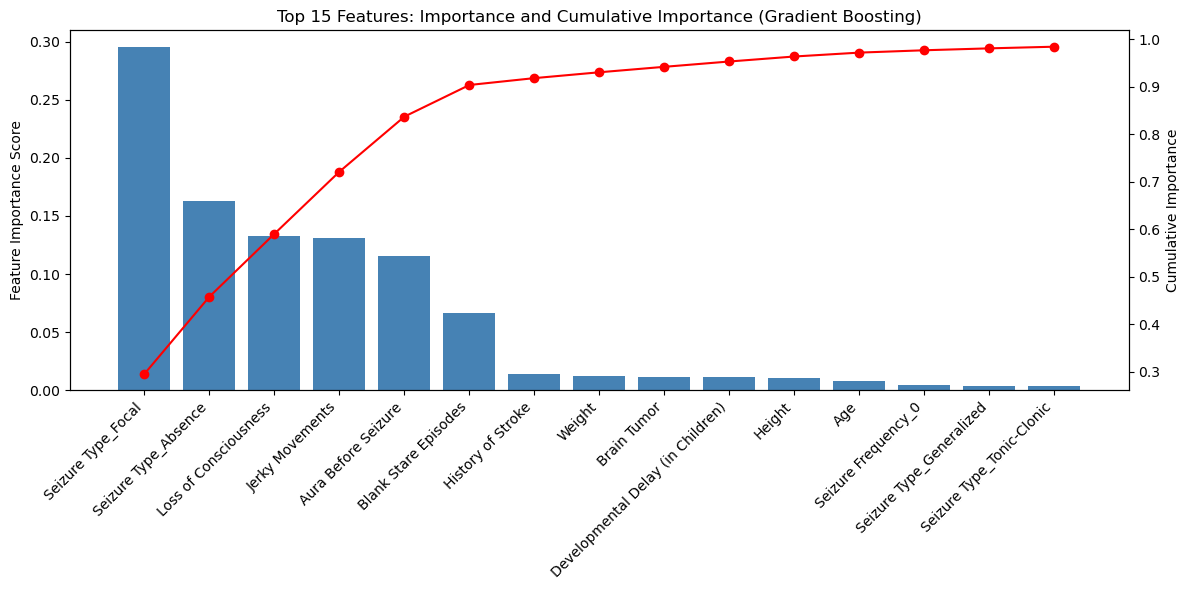

In [124]:
import matplotlib.pyplot as plt

gb_best_model = GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
best_model = gb_best_model.fit(X_train, y_train)

fi = pd.Series(best_model.feature_importances_, index=X_train.columns)

# Sort feature importances
fi_sorted = fi.sort_values(ascending=False)
top15 = fi_sorted.head(15)
print(top15)
cumsum_top15 = top15.cumsum()

# Graph of feature importance and cumsum of feature importance ----
fig, ax1 = plt.subplots(figsize=(12,6))

# bar plot
ax1.bar(top15.index, top15.values, color='steelblue', label='Feature Importance')
ax1.set_ylabel("Feature Importance Score")
ax1.set_xticklabels(top15.index, rotation=45, ha="right")

# line plot 
ax2 = ax1.twinx()
ax2.plot(top15.index, cumsum_top15.values, color='red', marker='o', label='Cumulative Importance')
ax2.set_ylabel("Cumulative Importance")

# format
plt.title("Top 15 Features: Importance and Cumulative Importance (Gradient Boosting)")
plt.tight_layout()
plt.savefig("feature_selection.png")

Since majority of features contribute almost nothing to prediction, we will reduce the number of features used for prediction and determine if the accuracy an F1 scores are affected.

In [128]:
top_15 = fi.sort_values(ascending=False).head(15)
top15_sum = top_15.sum()
print("Sum of top-15 feature importance:", top15_sum)

Sum of top-15 feature importance: 0.983988823626275


Keeping the top 15 features can explain ~98% of variance in the data. We will proceed to predict using these top k features only.

In [130]:
# Prediction using gradient boosting and top 10 features 

X_train_subset = X_train[top_15.index]
X_test_subset = X_test[top_15.index]

gb_best_model.fit(X_train_subset, y_train)
y_pred_subset = gb_best_model.predict(X_test_subset)

f1_topk = f1_score(y_test, y_pred_subset, average="weighted")
acc_topk = accuracy_score(y_test, y_pred_subset)

print("F1 (weighted) score for top 15 features:", f1_topk)
print("Accuracy score for top 15 features:", acc_topk)

F1 (weighted) score for top 15 features: 0.7937179977966116
Accuracy score for top 15 features: 0.8076131687242798
